# ReadTheDocs Traffic Analysis

The purpose of this notebook is to plot the visitor numbers to the TOM Toolkit ReadTheDocs pages

In [15]:
from os import path
import pandas as pd
import argparse
import glob
import numpy as np
from astropy.table import Table, Column
import matplotlib.pyplot as plt
from matplotlib.dates import (MONTHLY, DateFormatter,
                              rrulewrapper, RRuleLocator, drange)
from datetime import datetime

ReadTheDocs provides visitor numbers in the form of downloadable CSV files of data for the preceeding ~2 month window.  Charting data longer than this therefore requires us to combine data downloaded at intervals. 

In [3]:
def load_RTD_traffic_data(args):
    """
    Function to load traffic analysis data from ReadTheDocs in CSV
    format files into a Pandas dataframe
    """

    # ReadTheDocs allows users to download segments of ~3 months worth
    # of traffic analysis at a time, so the input data comes in the form
    # of a set of files whose data should be concatenated
    file_list = glob.glob(path.join(args['data_dir'], args['file_rootname'] + '*.csv'))

    for i,f in enumerate(file_list):
        if i == 0:
            df = pd.read_csv(f)
            print('Read ' + path.basename(f) + ' with ' + str(len(df)) + ' entries')
        else:
            new_data = pd.read_csv(f)
            df = pd.concat([df, new_data])
            print('Read concat ' + path.basename(f) + ' with ' + str(len(new_data)) + ' entries')

    traffic_data = Table.from_pandas(df.sort_values('Date'))

    return traffic_data


In [6]:
args = {
    'data_dir': '/Users/rstreet/TOMToolkit/ReadTheDocsStats',
    'file_rootname': 'readthedocs_traffic_analytics_tom-toolkit_'
}

traffic_data = load_RTD_traffic_data(args)
traffic_data

Read readthedocs_traffic_analytics_tom-toolkit_2024-02-08_2024-05-08.csv with 10917 entries
Read concat readthedocs_traffic_analytics_tom-toolkit_2025-01-31_2025-05-01.csv with 1029 entries
Read concat readthedocs_traffic_analytics_tom-toolkit_2025-03-21_2025-06-19.csv with 900 entries
Read concat readthedocs_traffic_analytics_tom-toolkit_2025-05-01_2025-07-30.csv with 841 entries
Read concat readthedocs_traffic_analytics_tom-toolkit_2024-05-01_2024-07-30.csv with 8703 entries
Read concat readthedocs_traffic_analytics_tom-toolkit_2023-11-10_2024-02-08.csv with 8200 entries
Read concat readthedocs_traffic_analytics_tom-toolkit_2025-07-30_2025-10-28.csv with 6536 entries
Read concat readthedocs_traffic_analytics_tom-toolkit_2024-12-18_2025-03-18.csv with 1131 entries


Date,Version,Path,Views
str19,str13,str47,int64
2023-11-10 00:00:00,stable,/managing_data/stream_pub_sub.html,1
2023-11-10 00:00:00,stable,/customization/customize_templates.html,1
2023-11-10 00:00:00,stable,/customization/index.html,1
2023-11-10 00:00:00,latest,/introduction/getting_started.html,1
2023-11-10 00:00:00,1.7.3,/index.html,1
2023-11-10 00:00:00,stable,/observing/index.html,1
2023-11-10 00:00:00,stable,/introduction/about.html,1
2023-11-10 00:00:00,stable,/code/index.html,1
2023-11-10 00:00:00,latest,/introduction/index.html,1


ReadTheDocs unfortunately changed how they compile visitor numbers.  Prior to Dec 2024, they relied on Google Analytics, but when this system went away they replaced it with their own metrics.  So for consistency, we plot the figures after this date. 

In [23]:
def sum_over_dates(traffic_data):
    """
    Function to sum the traffic data by date; the CSV files have multiple entries
    for each data, relating to the number of views per page of the documentation.
    Since we want to plot the total number of views per day, we need to sum
    over each date

    :param traffic_data:
    :return:
    """

    dates = []
    total_views = []
    for i,date in enumerate(traffic_data['Date']):
        idx = traffic_data['Date'] == date
        clean_date = pd.to_datetime(date, format='%Y-%m-%d %H:%M:%S')
        dates.append(clean_date)
        total_views.append(traffic_data['Views'][idx].sum())

    traffic_stats = Table([
        Column(name='Date', data=dates),
        Column(name='Views', data=total_views)
    ])

    # Downselect only dates after the change to visitor compilation metrics
    min_date = datetime.strptime('2024-12-03T00:00:00', '%Y-%m-%dT%H:%M:%S')
    jdx = traffic_stats['Date'] >= min_date 
    
    median_visits = np.median(traffic_stats[jdx]['Views'])
    print('Median number of views per day over date range: ' + str(median_visits))
    
    return traffic_stats[jdx]

In [24]:
traffic_stats = sum_over_dates(traffic_data)
traffic_stats

Median number of views per day over date range: 124.0


Date,Views
object,int64
2024-12-18 00:00:00,10
2024-12-18 00:00:00,10
2024-12-18 00:00:00,10
2024-12-18 00:00:00,10
2024-12-18 00:00:00,10
2024-12-18 00:00:00,10
2024-12-18 00:00:00,10
2024-12-18 00:00:00,10
2024-12-19 00:00:00,19


In [37]:
# Calculating the median monthly page views, excluding conference-related spike
max_date = datetime.strptime('2025-08-22T00:00:00', '%Y-%m-%dT%H:%M:%S')
jdx = traffic_stats['Date'] <= max_date 
median_visitors = np.median(traffic_stats[jdx]['Views'])
print('Median visitors excluding spike: ' + str(median_visitors))

Median visitors excluding spike: 36.0


Now let's plot the results

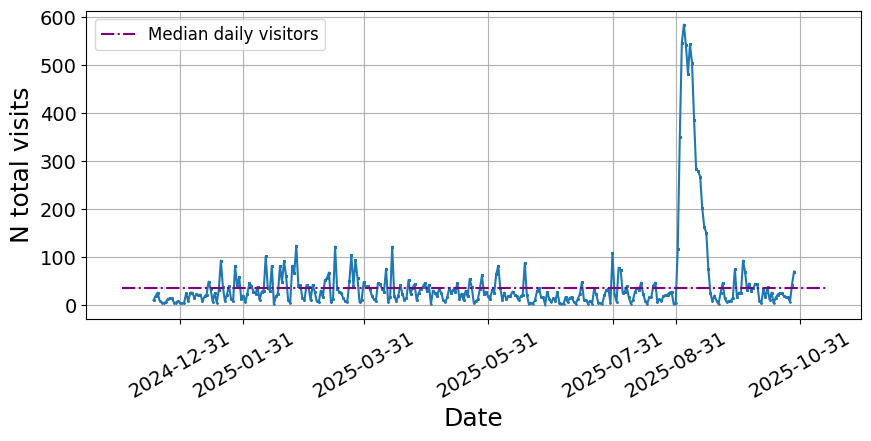

In [41]:
formatter = DateFormatter('%Y-%m-%d')
rule = rrulewrapper(MONTHLY, interval=1)
loc = RRuleLocator(rule)

fig, ax = plt.subplots(figsize=(10,4))
plt.plot(traffic_stats['Date'], traffic_stats['Views'], marker='.', markersize=1, linestyle='-')
xmin, xmax = ax.get_xlim()
plt.plot([xmin, xmax], [median_visitors, median_visitors], c='purple', linestyle='-.', label='Median daily visitors')
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(formatter)
ax.xaxis.set_tick_params(rotation=30, labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.grid()
plt.xlabel('Date', fontsize=18)
plt.ylabel('N total visits', fontsize=18)
plt.legend(fontsize=12)

plt.savefig(
    path.join(args['data_dir'], 'tomtoolkit_RTD_visits_per_day.png'),
    bbox_inches='tight'
)